In [1]:
import os, re

import matplotlib.pyplot as plt

import numpy as np
import torch
import torch_geometric
from torch_geometric.data import Data

In [2]:
from utils import get_ordered_body_coords


In [3]:
graph = torch.load('/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed/DSE-DACE200_workdir10.pt', weights_only=False)

In [4]:
get_ordered_body_coords(graph).shape

torch.Size([158, 2])

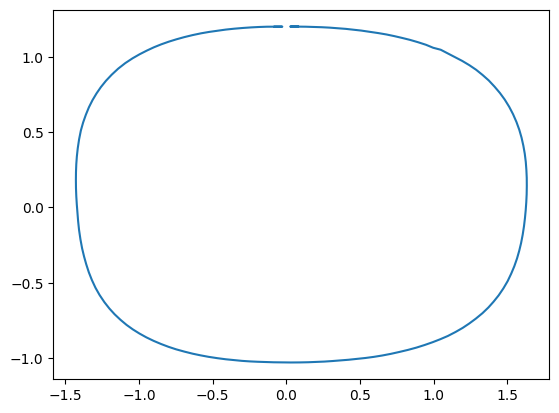

In [6]:
bc = get_ordered_body_coords(graph)
plt.plot(bc[:,0], bc[:,1])

In [16]:
from utils_potential import body_panels, sol_pot, mk_coeff_xy
from utils import get_ordered_body_coords
from plot_utils import plot_field
import pandas as pd

In [17]:
def get_potential_solution(graph):
    xycpan, xpan, ypan, thpan, nor = body_panels(get_ordered_body_coords(graph).numpy()) # (N,2)
    sigma_x, sigma_y = sol_pot(xycpan, xpan, ypan, thpan, nor)
    Ax_field, Ay_field = mk_coeff_xy(graph.pos[graph.node_type_one_hot[:,0]==0].numpy(), thpan, xpan, ypan)
    u_pot_field = np.matmul(Ax_field, sigma_x) + np.matmul(Ax_field, 0*sigma_y) + 1
    u_pot_field = torch.from_numpy(u_pot_field).float()
    v_pot_field = np.matmul(Ay_field, sigma_x) + np.matmul(Ay_field, 0*sigma_y) + 0
    v_pot_field = torch.from_numpy(v_pot_field).float()
    potential_solution = torch.zeros_like(graph.pos)
    potential_solution[graph.node_type_one_hot[:,0]==0] = torch.cat([u_pot_field, v_pot_field], dim=1)
    return potential_solution

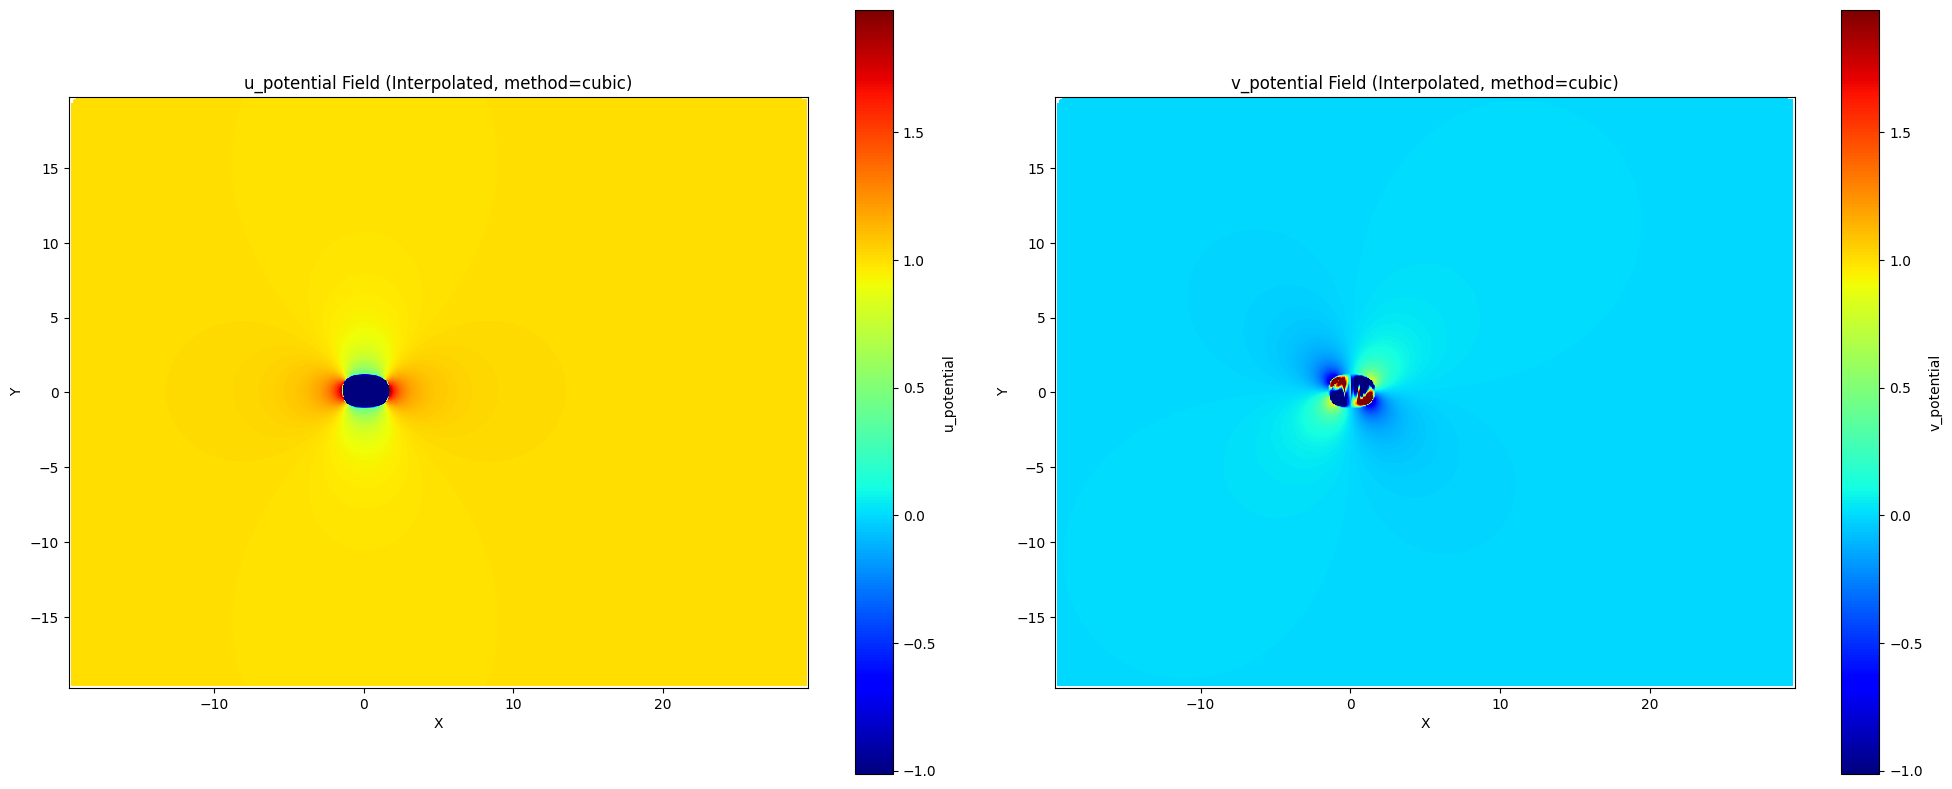

In [19]:
graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

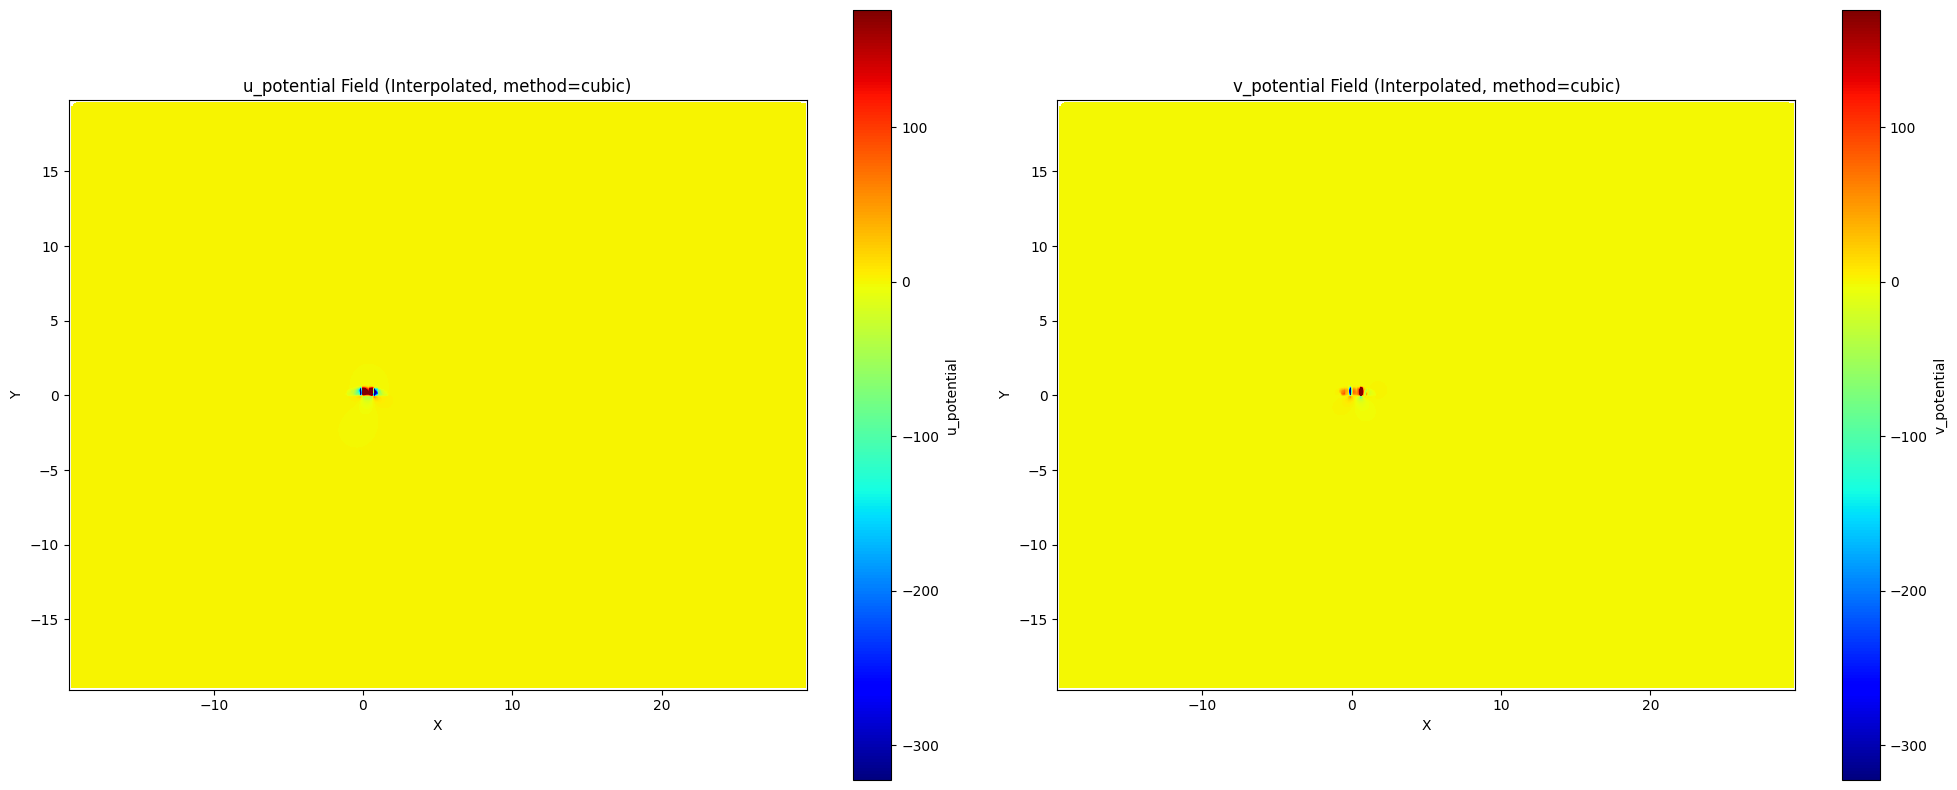

In [ ]:
geom_idx = 122
graph = torch.load(f'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed_old/DSE-DACE500_workdir{geom_idx}.pt', weights_only=False)
def extract_bspline_points(file_path):
    with open(file_path) as f:
        line = f.read().split()
    points = [float(p) for p in line]
    return torch.tensor(points) # west_x, east_x, north_y, south_y

graph.bspline_points = extract_bspline_points(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/input.txt')

graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

body_mask = graph.node_type_one_hot[:,0] == 1
pos_body = graph.pos[body_mask]
check = pos_body[:,1].min() > graph.bspline_points[-1] and pos_body[:,1].max() < graph.bspline_points[-2]
print('check', check)

plt.scatter(pos_body[:,0], pos_body[:,1])
plt.show()

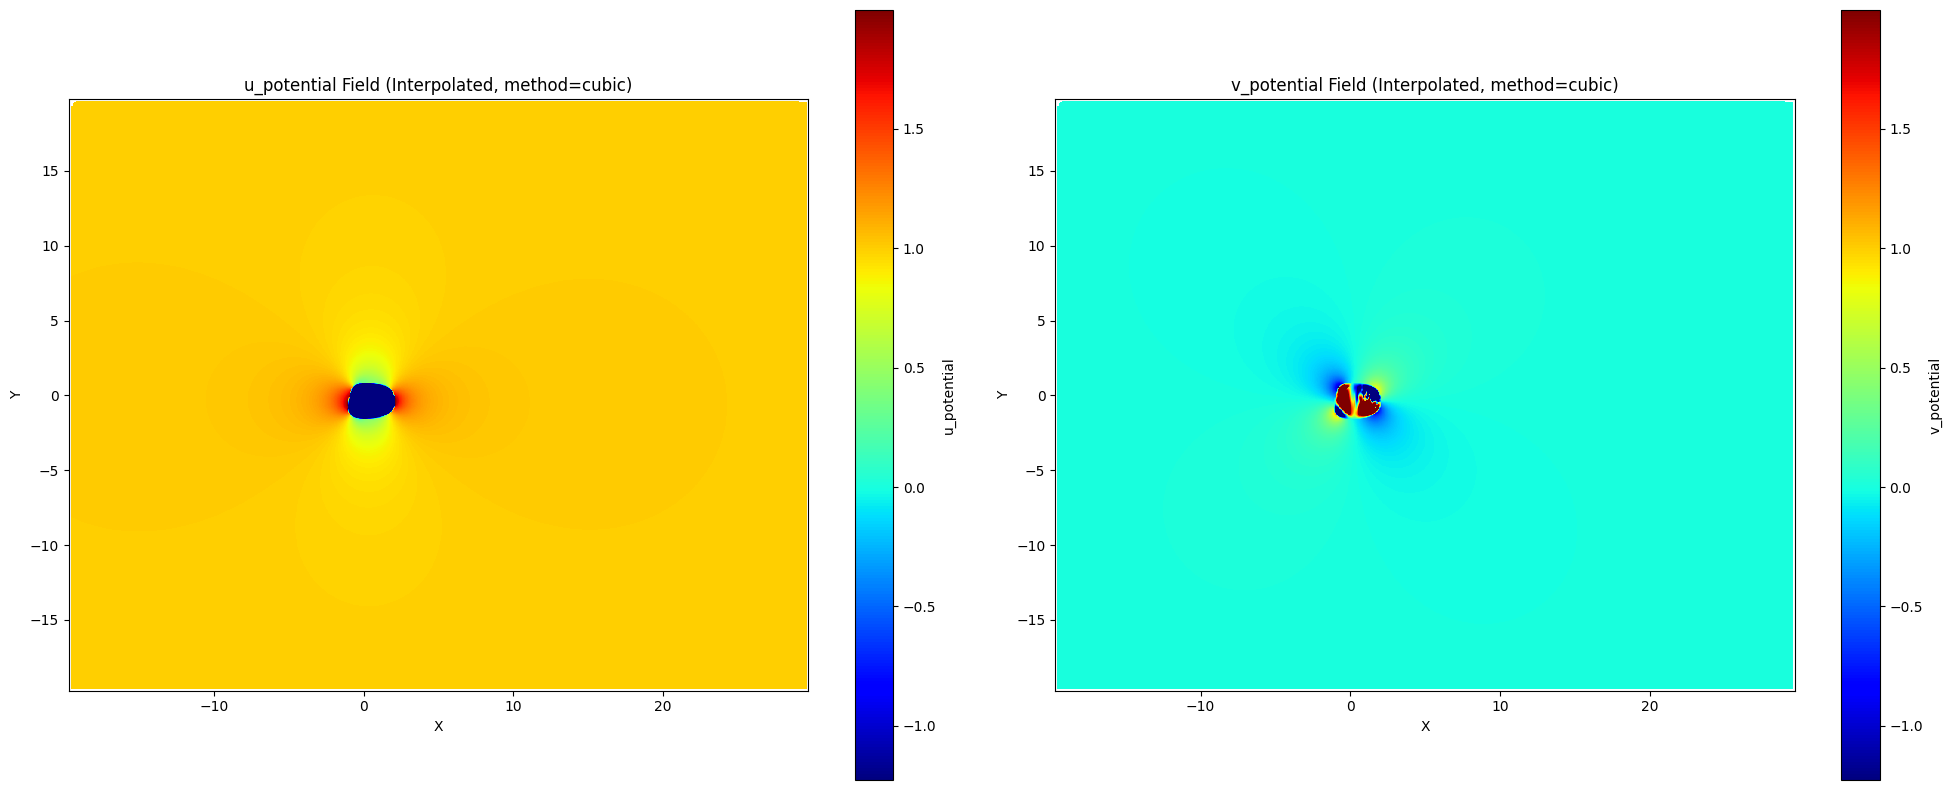

check tensor(False)


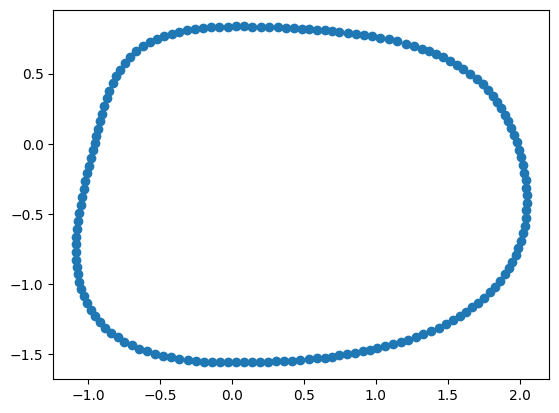

In [40]:
geom_idx = 121
graph = torch.load(f'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed_old/DSE-DACE500_workdir{geom_idx}.pt', weights_only=False)
def extract_bspline_points(file_path):
    with open(file_path) as f:
        line = f.read().split()
    points = [float(p) for p in line]
    return torch.tensor(points) # west_x, east_x, north_y, south_y

graph.bspline_points = extract_bspline_points(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/input.txt')

graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

body_mask = graph.node_type_one_hot[:,0] == 1
pos_body = graph.pos[body_mask]
check = pos_body[:,1].min() > graph.bspline_points[-1] and pos_body[:,1].max() < graph.bspline_points[-2]
print('check', check)

plt.scatter(pos_body[:,0], pos_body[:,1])
plt.show()

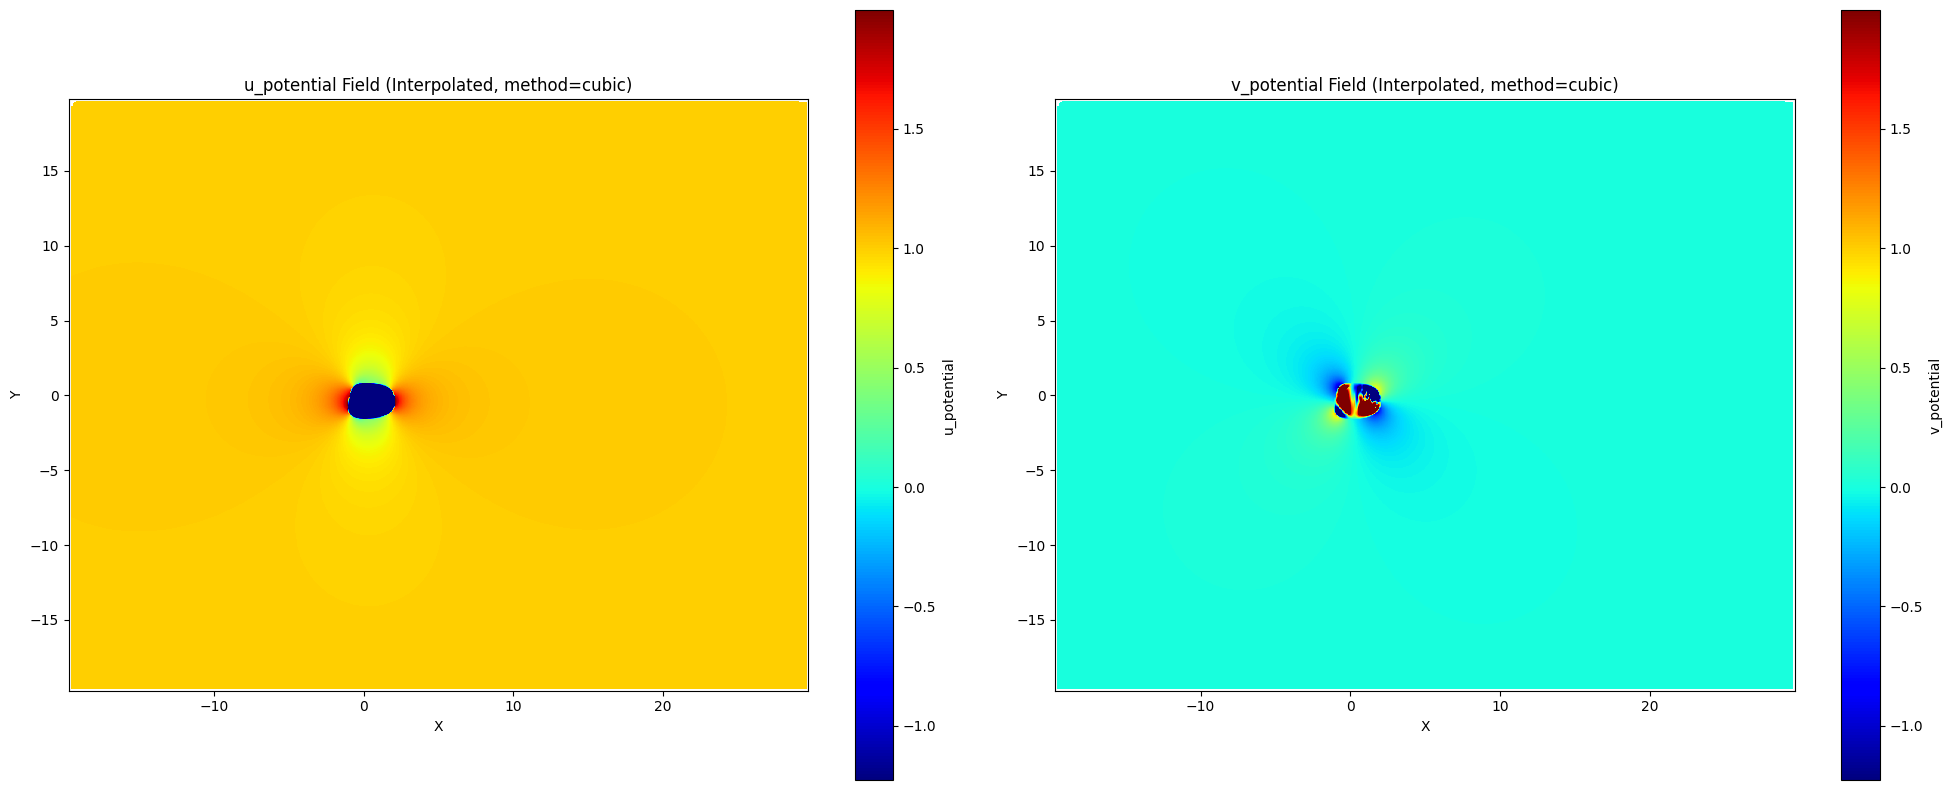

check tensor(False)


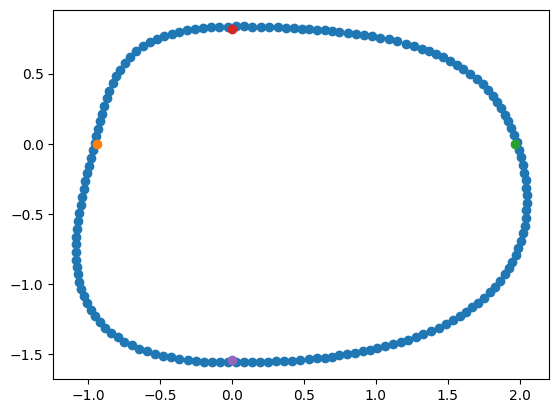

In [ ]:
geom_idx = 121
graph = torch.load(f'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed_old/DSE-DACE500_workdir{geom_idx}.pt', weights_only=False)
def extract_bspline_points(file_path):
    with open(file_path) as f:
        line = f.read().split()
    points = [float(p) for p in line]
    return torch.tensor(points) # west_x, east_x, north_y, south_y

graph.bspline_points = extract_bspline_points(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/input.txt')

graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

body_mask = graph.node_type_one_hot[:,0] == 1
pos_body = graph.pos[body_mask]
check = pos_body[:,1].min() > graph.bspline_points[-1] and pos_body[:,1].max() < graph.bspline_points[-2]
print('check', check)

plt.scatter(pos_body[:,0], pos_body[:,1])
plt.scatter(graph.bspline_points[0], 0)
plt.scatter(graph.bspline_points[1], 0)
plt.scatter(0, graph.bspline_points[2])
plt.scatter(0, graph.bspline_points[3])
plt.scatter

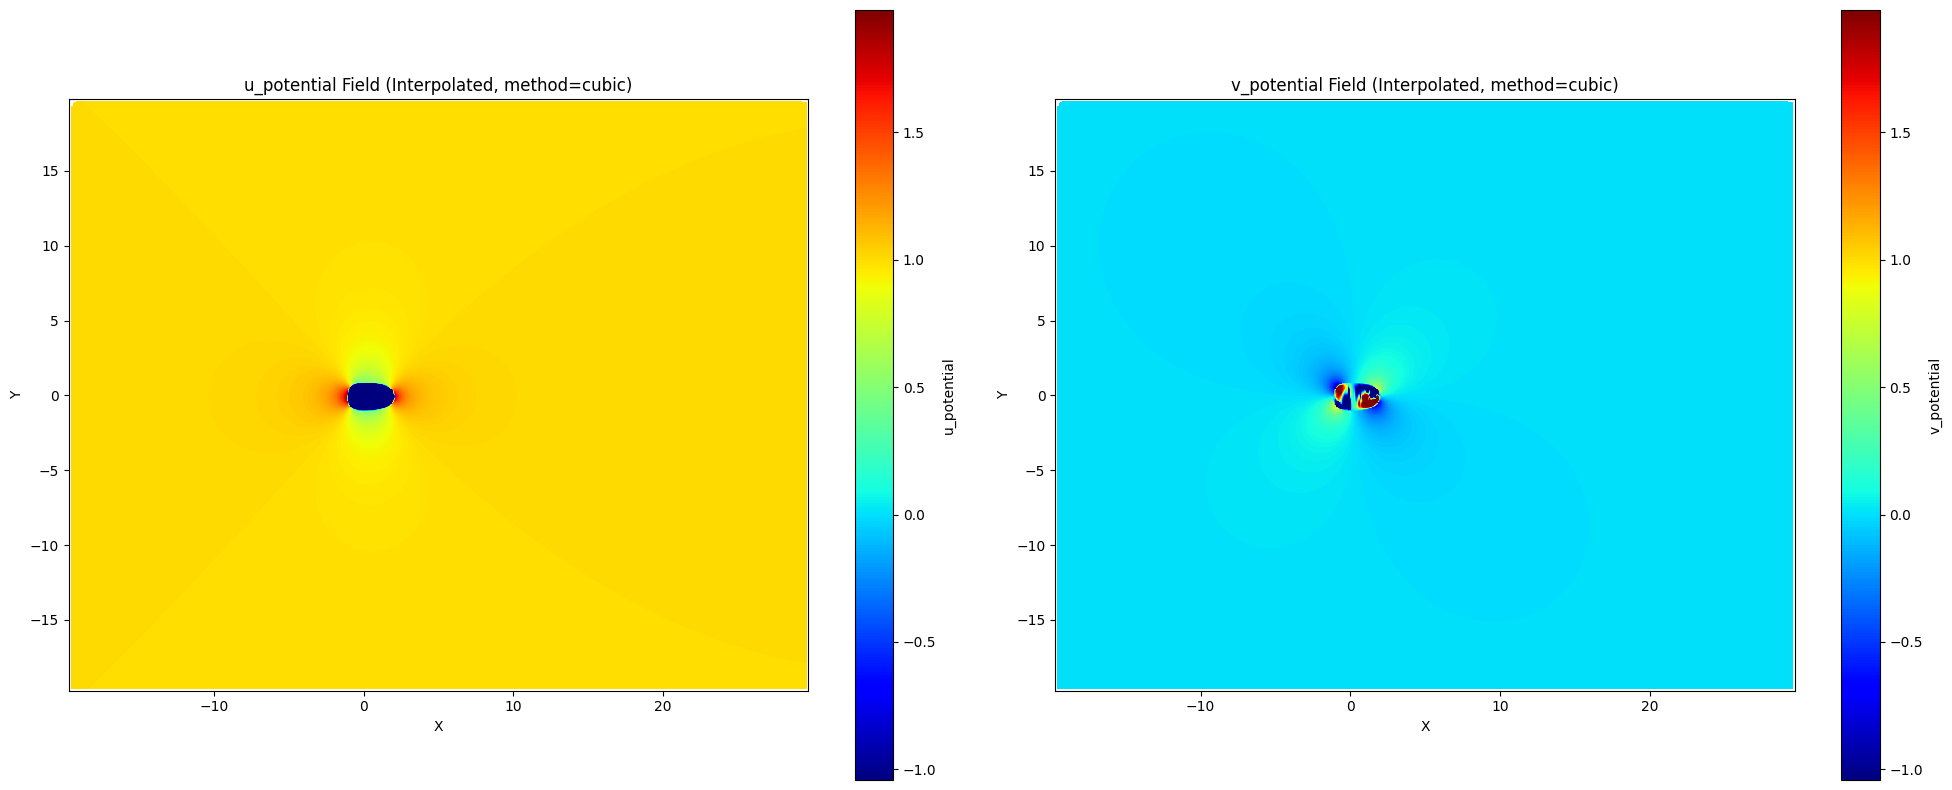

check tensor(True)


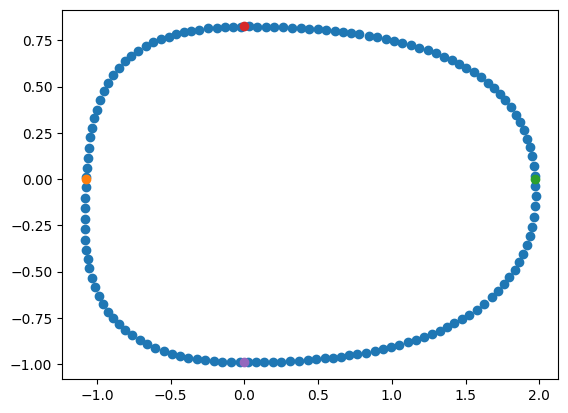

In [70]:
geom_idx = 489
graph = torch.load(f'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto/data/train/processed_old/DSE-DACE500_workdir{geom_idx}.pt', weights_only=False)
def extract_bspline_points(file_path):
    with open(file_path) as f:
        line = f.read().split()
    points = [float(p) for p in line]
    return torch.tensor(points) # west_x, east_x, north_y, south_y

graph.bspline_points = extract_bspline_points(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/input.txt')

graph.potential_solution = get_potential_solution(graph)

df = pd.DataFrame({'X': graph.pos[:,0], 'Y': graph.pos[:,1], 'u_potential': graph.potential_solution[:,0], 'v_potential': graph.potential_solution[:,1] })
plot_field(df, variable=['u_potential', 'v_potential'], grid_resolution=500)

with open(f'./data/train/raw/DSE-DACE500/workdir.{geom_idx}/1000/C', 'r') as f:
    lines = f.read().splitlines()
prof_extruded_line = lines.index('    prof_extruded')
n = int(lines[prof_extruded_line + 4])
body_pos = torch.tensor([[float(c) for c in line[1:-1].split()[:2]] for line in lines[prof_extruded_line+6 : prof_extruded_line+6+n]])
check = pos_body[:,1].min() - graph.bspline_points[-1] > -0.05 and pos_body[:,1].max() - graph.bspline_points[-2] < 0.05
print('check', check)

plt.scatter(body_pos[:,0], body_pos[:,1])
plt.scatter(graph.bspline_points[0], 0)
plt.scatter(graph.bspline_points[1], 0)
plt.scatter(0, graph.bspline_points[2])
plt.scatter(0, graph.bspline_points[3])

In [ ]:
with open(f'./data/test/raw/DSE-DACE100/workdir.{geom_idx}/1000/C', 'r') as f:
    lines = f.read().splitlines()
prof_extruded_line = lines.index('    prof_extruded')
n = int(lines[prof_extruded_line + 4])
body = [[float(c) for c in line[1:-1].split()[:2]] for line in lines[prof_extruded_line+6 : prof_extruded_line+6+n]]
body[0]

[-0.02826356103, -1.526412723]

In [1]:
from define_dataset import MyOwnDataset
import yaml
folder = 'experiment1'
with open(f'./{folder}/config.yaml', 'r') as f:
    metadata = yaml.safe_load(f)
metadata['experiment_folder'] = folder
dataset = MyOwnDataset(metadata, split='test')

In [74]:
import pickle
with open('./data/train/processed/filenames.pkl', 'rb') as f:
    filenames = pickle.load(f)
filenames

['DSE-DACE200_workdir1.pt',
 'DSE-DACE200_workdir2.pt',
 'DSE-DACE200_workdir4.pt',
 'DSE-DACE200_workdir5.pt',
 'DSE-DACE200_workdir6.pt',
 'DSE-DACE200_workdir7.pt',
 'DSE-DACE200_workdir8.pt',
 'DSE-DACE200_workdir9.pt',
 'DSE-DACE200_workdir10.pt',
 'DSE-DACE200_workdir11.pt',
 'DSE-DACE200_workdir12.pt',
 'DSE-DACE200_workdir13.pt',
 'DSE-DACE200_workdir16.pt',
 'DSE-DACE200_workdir17.pt',
 'DSE-DACE200_workdir18.pt',
 'DSE-DACE200_workdir19.pt',
 'DSE-DACE200_workdir20.pt',
 'DSE-DACE200_workdir21.pt',
 'DSE-DACE200_workdir22.pt',
 'DSE-DACE200_workdir23.pt',
 'DSE-DACE200_workdir24.pt',
 'DSE-DACE200_workdir26.pt',
 'DSE-DACE200_workdir27.pt',
 'DSE-DACE200_workdir28.pt',
 'DSE-DACE200_workdir29.pt',
 'DSE-DACE200_workdir30.pt',
 'DSE-DACE200_workdir31.pt',
 'DSE-DACE200_workdir32.pt',
 'DSE-DACE200_workdir33.pt',
 'DSE-DACE200_workdir34.pt',
 'DSE-DACE200_workdir35.pt',
 'DSE-DACE200_workdir36.pt',
 'DSE-DACE200_workdir37.pt',
 'DSE-DACE200_workdir38.pt',
 'DSE-DACE200_workdir3

In [4]:
import torch
mean = torch.load('./data/train/processed/mean_N[200, 500].pt')
std = torch.load('./data/train/processed/std_N[200, 500].pt')

mean, std

({'distance_vector': tensor([-6.0205e-12, -7.8297e-12]),
  'distance_magnitude': tensor([0.3604]),
  'velocity': tensor([ 8.2920e-01, -3.3381e-04]),
  'velocity_mean': tensor([ 8.3418e-01, -2.6783e-04]),
  'pressure': tensor([-0.0458]),
  'pressure_mean': tensor([-0.0470]),
  'distance_from_obj_vec': tensor([2.7842, 0.3858]),
  'distance_from_obj_mag': tensor([11.0452]),
  'potential_solution': tensor([9.8256e-01, 1.8777e-04])},
 {'distance_vector': tensor([0.3112, 0.3006]),
  'distance_magnitude': tensor([0.2393]),
  'velocity': tensor([0.3756, 0.1511]),
  'velocity_mean': tensor([0.3682, 0.1492]),
  'pressure': tensor([0.1597]),
  'pressure_mean': tensor([0.1624]),
  'distance_from_obj_vec': tensor([11.1705,  8.9104]),
  'distance_from_obj_mag': tensor([9.4910]),
  'potential_solution': tensor([0.3135, 0.2840])})

## Topology

### Owner

In [50]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/owner'

with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       labelList;',
 '    note        "nPoints: 9026 nCells: 8702 nFaces: 30619 nInternalFaces: 12891";',
 '    location    "constant/polyMesh";',
 '    object      owner;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 '',
 '30619',
 '(',
 '0',
 '1',
 '1',
 '2',
 '2',
 '3',
 '4',
 '4',
 '5',
 '6',
 '6',
 '7',
 '8',
 '8',
 '9',
 '10',
 '10',
 '11',
 '12',
 '12',
 '13',
 '14',
 '14',
 '15',
 '16',
 '16',
 '17',
 '18',
 '18',
 '19',
 '20',
 '20',
 '21',
 '22',


In [51]:
lines[18], lines[20], lines[21], int(lines[20]), lines[-1], lines[20+int(lines[18])-1], lines[20+int(lines[18])]

('30619',
 '0',
 '1',
 0,
 '// ************************************************************************* //',
 '8701',
 ')')

In [52]:
with open(file, 'r') as f:
    lines = f.read().splitlines()

n_owners = int(lines[18])
owners = torch.tensor([int(o) for o in lines[20:20+n_owners]])

In [53]:
[(owners==idx).sum() for idx in [10,123, 124, 7333]], len(owners)

([tensor(5), tensor(3), tensor(5), tensor(3)], 30619)

### Neighbours

In [35]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/neighbour'

with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       labelList;',
 '    note        "nPoints: 9026 nCells: 8702 nFaces: 30619 nInternalFaces: 12891";',
 '    location    "constant/polyMesh";',
 '    object      neighbour;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 '',
 '12891',
 '(',
 '424',
 '3',
 '639',
 '3',
 '5',
 '963',
 '5',
 '7',
 '641',
 '7',
 '9',
 '642',
 '9',
 '11',
 '644',
 '11',
 '13',
 '646',
 '13',
 '15',
 '648',
 '15',
 '17',
 '650',
 '17',
 '19',
 '652',
 '19',
 '21',
 '654',
 '21',

In [36]:
lines[18], lines[19], lines[20], lines[21], int(lines[20]), lines[-1], lines[20+int(lines[18])-1], lines[20+int(lines[18])]

('12891',
 '(',
 '424',
 '3',
 424,
 '// ************************************************************************* //',
 '8699',
 ')')

In [37]:
with open(file, 'r') as f:
    lines = f.read().splitlines()

n_neigh = int(lines[18])
neigh = torch.tensor([int(o) for o in lines[20:20+n_neigh]])

In [38]:
neigh.unique().shape

torch.Size([8377])

### Edge_index

In [108]:
edge_index = torch.stack([neigh, owners[:len(neigh)]])
edge_index = torch.cat([edge_index, edge_index.flip(dims=[0])], dim=1)
edge_index

tensor([[ 424,    3,  639,  ..., 8694, 8694, 8697],
        [   0,    1,    1,  ..., 8695, 8696, 8699]])

In [109]:
a = torch.arange(10).reshape((2,5))
a, a.flip(dims=[0])

(tensor([[0, 1, 2, 3, 4],
         [5, 6, 7, 8, 9]]),
 tensor([[5, 6, 7, 8, 9],
         [0, 1, 2, 3, 4]]))

## Centers

In [40]:
file = './data/DSE-DACE200/workdir.1/1000/C'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       volVectorField;',
 '    location    "1000";',
 '    object      C;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 'dimensions      [0 1 0 0 0 0 0];',
 '',
 'internalField   nonuniform List<vector> ',
 '8702',
 '(',
 '(-19.66666667 -19.66666667 0.5)',
 '(-19.71584619 -18.45156643 0.5)',
 '(-19.69488513 -17.48741301 0.5)',
 '(-19.41073132 -17.93897944 0.5)',
 '(-19.70017645 -16.49312349 0.5)',
 '(-19.39506158 -16.9805365 0.5)',
 '(-19.70566807 -15.49504

In [41]:
# to extract all of them
pattern = r"^\((\s*-?\d+(\.\d*)?)\s+(-?\d+(\.\d*)?)\s+(-?\d+(\.\d*)?)\)$"
positions = []
for line in lines:
    if re.match(pattern, line):
        positions.append([float(p) for p in line[1:-1].split()[:2]])  # discard the 3rd as it is the z variable


In [42]:
len(positions), positions[-1]

(9016, [30.0, 18.5])

In [43]:
lines[19], lines[21],  lines[21][1:-1], lines

('8702',
 '(-19.66666667 -19.66666667 0.5)',
 '-19.66666667 -19.66666667 0.5',
 ['/*--------------------------------*- C++ -*----------------------------------*\\',
  '  =========                 |',
  '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
  '   \\\\    /   O peration     | Website:  https://openfoam.org',
  '    \\\\  /    A nd           | Version:  12',
  '     \\\\/     M anipulation  |',
  '\\*---------------------------------------------------------------------------*/',
  'FoamFile',
  '{',
  '    format      ascii;',
  '    class       volVectorField;',
  '    location    "1000";',
  '    object      C;',
  '}',
  '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
  '',
  'dimensions      [0 1 0 0 0 0 0];',
  '',
  'internalField   nonuniform List<vector> ',
  '8702',
  '(',
  '(-19.66666667 -19.66666667 0.5)',
  '(-19.71584619 -18.45156643 0.5)',
  '(-19.69488513 -17.48741301 0.5)',
  '(-19.41073132 -17.93897944

In [45]:
# I only need the internal fields one
n_centers = int(lines[19])
centers = torch.tensor([[float(c) for c in center[1:-1].split()[:2]] for center in lines[21:21+n_centers]])
centers.shape, centers

(torch.Size([8702, 2]),
 tensor([[-19.6667, -19.6667],
         [-19.7158, -18.4516],
         [-19.6949, -17.4874],
         ...,
         [  5.7667,   0.1637],
         [  9.4874,   0.6403],
         [  6.2616,  -1.4845]]))

## Points

In [82]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/points'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       vectorField;',
 '    location    "constant/polyMesh";',
 '    object      points;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 '',
 '9026',
 '(',
 '(0 0.9165078119 0)',
 '(0 -1.33313281 0)',
 '(30 20 0)',
 '(30 -20 0)',
 '(-20 20 0)',
 '(-20 -20 0)',
 '(-20 -19 0)',
 '(-20 -18 0)',
 '(-20 -17 0)',
 '(-20 -16 0)',
 '(-20 -15 0)',
 '(-20 -14 0)',
 '(-20 -13 0)',
 '(-20 -12 0)',
 '(-20 -11 0)',
 '(-20 -10 0)',
 '(-20 -9 0)',
 '(-20 -8 0)',
 '(-20 -7 0)

In [84]:
lines[17], lines[19]

('9026', '(0 0.9165078119 0)')

In [85]:
n_points = int(lines[17])
points = [[float(p) for p in point[1:-1].split()] for point in lines[19:19+n_points]]
points[-1], len(points)

([5.277175431, -0.2831196961, 1.0], 9026)

## Faces

In [76]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/faces'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       faceList;',
 '    location    "constant/polyMesh";',
 '    object      faces;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 '',
 '30619',
 '(',
 '4(6 4513 4515 45)',
 '4(7 4516 4517 324)',
 '4(6 324 4517 4513)',
 '4(7 325 4519 4516)',
 '4(8 4518 4519 325)',
 '4(324 325 4519 4517)',
 '4(8 326 4521 4518)',
 '4(9 4520 4521 326)',
 '4(325 326 4521 4519)',
 '4(9 327 4523 4520)',
 '4(10 4522 4523 327)',
 '4(326 327 4523 4521)',
 '4(10 328 4525 4522)',
 '4(

In [81]:
lines[17], lines[19], lines[19+int(lines[17])-1:]
n_faces = int(lines[17])
faces = [ [int(f) for f in face[2:-1].split()] for face in lines[19:19+n_faces]]

len(faces), faces[-5:]

(30619,
 [[7563, 9016, 7480],
  [4481, 4505, 4500],
  [9012, 8240, 8860],
  [4502, 4506, 4492],
  [8345, 9022, 7299]])

In [87]:
faces[0]

[6, 4513, 4515, 45]

In [100]:
faces_with_points = [[points[f] for f in face] for face in faces]
faces_with_points

[[[-20.0, -19.0, 0.0],
  [-20.0, -19.0, 1.0],
  [-19.0, -20.0, 1.0],
  [-19.0, -20.0, 0.0]],
 [[-20.0, -18.0, 0.0],
  [-20.0, -18.0, 1.0],
  [-19.14753858, -18.35469928, 1.0],
  [-19.14753858, -18.35469928, 0.0]],
 [[-20.0, -19.0, 0.0],
  [-19.14753858, -18.35469928, 0.0],
  [-19.14753858, -18.35469928, 1.0],
  [-20.0, -19.0, 1.0]],
 [[-20.0, -18.0, 0.0],
  [-19.08465538, -17.46223904, 0.0],
  [-19.08465538, -17.46223904, 1.0],
  [-20.0, -18.0, 1.0]],
 [[-20.0, -17.0, 0.0],
  [-20.0, -17.0, 1.0],
  [-19.08465538, -17.46223904, 1.0],
  [-19.08465538, -17.46223904, 0.0]],
 [[-19.14753858, -18.35469928, 0.0],
  [-19.08465538, -17.46223904, 0.0],
  [-19.08465538, -17.46223904, 1.0],
  [-19.14753858, -18.35469928, 1.0]],
 [[-20.0, -17.0, 0.0],
  [-19.10052936, -16.47937047, 0.0],
  [-19.10052936, -16.47937047, 1.0],
  [-20.0, -17.0, 1.0]],
 [[-20.0, -16.0, 0.0],
  [-20.0, -16.0, 1.0],
  [-19.10052936, -16.47937047, 1.0],
  [-19.10052936, -16.47937047, 0.0]],
 [[-19.08465538, -17.46223904, 0

In [101]:
faces_with_points[0]

[[-20.0, -19.0, 0.0],
 [-20.0, -19.0, 1.0],
 [-19.0, -20.0, 1.0],
 [-19.0, -20.0, 0.0]]

In [103]:
idx0 = torch.arange(len(owners))[owners==0]
faces0 = [faces_with_points[i] for i in idx0]
faces0

[[[-20.0, -19.0, 0.0],
  [-20.0, -19.0, 1.0],
  [-19.0, -20.0, 1.0],
  [-19.0, -20.0, 0.0]],
 [[-20.0, -20.0, 0.0],
  [-19.0, -20.0, 0.0],
  [-19.0, -20.0, 1.0],
  [-20.0, -20.0, 1.0]],
 [[-20.0, -19.0, 0.0],
  [-20.0, -20.0, 0.0],
  [-20.0, -20.0, 1.0],
  [-20.0, -19.0, 1.0]],
 [[-20.0, -19.0, 0.0], [-19.0, -20.0, 0.0], [-20.0, -20.0, 0.0]],
 [[-20.0, -19.0, 1.0], [-20.0, -20.0, 1.0], [-19.0, -20.0, 1.0]]]

In [108]:
points_faces0 = torch.tensor([f for face in faces0 for f in face])
points_faces0.mean(dim=0)

tensor([-19.6667, -19.6667,   0.5000])

In [109]:
idx0 = torch.arange(len(owners))[owners==1]
faces0 = [faces_with_points[i] for i in idx0]
faces0
points_faces0 = torch.tensor([f for face in faces0 for f in face])
points_faces0.mean(dim=0)

tensor([-19.7158, -18.4516,   0.5000])

## Node type

In [66]:
file = './data/DSE-DACE200/workdir.1/constant/polyMesh/boundary'
with open(file, 'r') as f:
    lines = f.read()
lines

'/*--------------------------------*- C++ -*----------------------------------*\\\n  =========                 |\n  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox\n   \\\\    /   O peration     | Website:  https://openfoam.org\n    \\\\  /    A nd           | Version:  12\n     \\\\/     M anipulation  |\n\\*---------------------------------------------------------------------------*/\nFoamFile\n{\n    format          ascii;\n    class           polyBoundaryMesh;\n    location        "constant/polyMesh";\n    object          boundary;\n}\n// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //\n\n\n5\n(\n    prof_extruded\n    {\n        type            patch;\n        nFaces          144;\n        startFace       12891;\n    }\n    free_extruded\n    {\n        type            patch;\n        nFaces          100;\n        startFace       13035;\n    }\n    in_extruded\n    {\n        type            patch;\n        nFaces          40;\n    

In [68]:
patch_pattern = re.compile(
    r'(\w+)\s*\{\s*[^}]*?nFaces\s+(\d+);\s*startFace\s+(\d+);',
    re.MULTILINE | re.DOTALL
)

patches = {}
for match in patch_pattern.finditer(lines):
    patch_name = match.group(1)
    nFaces = int(match.group(2))
    startFace = int(match.group(3))
    patches[patch_name] = {
        'nFaces': nFaces,
        'startFace': startFace
    }

del patches['defaultFaces']
patches

{'prof_extruded': {'nFaces': 144, 'startFace': 12891},
 'free_extruded': {'nFaces': 100, 'startFace': 13035},
 'in_extruded': {'nFaces': 40, 'startFace': 13135},
 'out_extruded': {'nFaces': 40, 'startFace': 13175}}

In [91]:
nodes_of_each_type = {key: owners[patches[key]['startFace']:patches[key]['startFace']+patches[key]['nFaces']] for key in patches.keys()}

In [97]:
node_type_one_hot = torch.zeros(size=(len(owners.unique()), len(patches.keys())+1))

for i,key in enumerate(patches.keys()):
    node_type_one_hot[nodes_of_each_type[key],i] = 1

node_type_one_hot[node_type_one_hot.sum(axis=1)==0,-1] = 1

node_type_one_hot

tensor([[0., 1., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        ...,
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.]])

In [98]:
sum(node_type_one_hot.sum(axis=1)==2)

tensor(3)

## Edge attributes

In [101]:
distance_vector = centers[edge_index[0]] - centers[edge_index[1]]
distance_magnitude = torch.linalg.norm(distance_vector, dim=-1)
distance_vector, distance_magnitude

(tensor([[ 0.4625,  0.2925],
         [ 0.3051,  0.5126],
         [ 0.4625, -0.3741],
         ...,
         [ 0.4471, -0.3763],
         [-0.4283, -0.1311],
         [ 0.2192,  0.2205]]),
 tensor([0.5472, 0.5965, 0.5949,  ..., 0.5844, 0.4479, 0.3109]))

## U

In [111]:
file = './data/DSE-DACE200/workdir.1/1000/U'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       volVectorField;',
 '    location    "1000";',
 '    object      U;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 'dimensions      [0 1 -1 0 0 0 0];',
 '',
 'internalField   nonuniform List<vector> ',
 '8702',
 '(',
 '(1.00000587 8.741495854e-06 0)',
 '(1.000013775 -8.028546933e-05 3.756355067e-19)',
 '(1.000011873 -0.0001588965919 0)',
 '(1.000070042 -0.000252858011 0)',
 '(1.000009145 -0.0002070539042 0)',
 '(1.00004641 -0.0003732154059 0)',
 '(1.00

In [114]:
lines[19], lines[21]

('8702', '(1.00000587 8.741495854e-06 0)')

In [ ]:
n = int(lines[19])
out = torch.tensor([[float(l) for l in line[1:-1].split()[:2]] for line in lines[21:21+n]])
out

[[1.00000587, 8.741495854e-06],
 [1.000013775, -8.028546933e-05],
 [1.000011873, -0.0001588965919],
 [1.000070042, -0.000252858011],
 [1.000009145, -0.0002070539042],
 [1.00004641, -0.0003732154059],
 [1.000009211, -0.0002575133598],
 [1.000045869, -0.0004723412405],
 [1.000008041, -0.0003033730862],
 [1.000043622, -0.000571977262],
 [1.000007217, -0.0003463975263],
 [1.000039341, -0.000664865803],
 [1.000006085, -0.0003861519366],
 [1.000034707, -0.0007503663071],
 [1.000004299, -0.0004202851918],
 [1.000029546, -0.0008265044404],
 [1.000002392, -0.0004459075716],
 [1.00002281, -0.0008884450468],
 [1.000000512, -0.000461376265],
 [1.000014447, -0.0009315836007],
 [0.9999985098, -0.0004651952761],
 [1.000007555, -0.000953654325],
 [0.999996908, -0.0004564223372],
 [0.9999954063, -0.0009515233789],
 [0.9999949369, -0.0004341928673],
 [0.9999851734, -0.0009230393598],
 [0.9999929443, -0.0003981757024],
 [0.9999741152, -0.0008675863332],
 [0.9999910238, -0.0003485638135],
 [0.9999631572, 

## C

In [117]:
file = './data/DSE-DACE200/workdir.1/1000/C'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       volVectorField;',
 '    location    "1000";',
 '    object      C;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 'dimensions      [0 1 0 0 0 0 0];',
 '',
 'internalField   nonuniform List<vector> ',
 '8702',
 '(',
 '(-19.66666667 -19.66666667 0.5)',
 '(-19.71584619 -18.45156643 0.5)',
 '(-19.69488513 -17.48741301 0.5)',
 '(-19.41073132 -17.93897944 0.5)',
 '(-19.70017645 -16.49312349 0.5)',
 '(-19.39506158 -16.9805365 0.5)',
 '(-19.70566807 -15.49504

In [119]:
lines[19], lines[21]

('8702', '(-19.66666667 -19.66666667 0.5)')

## Pressure

In [120]:
file = './data/DSE-DACE200/workdir.1/1000/p'
with open(file, 'r') as f:
    lines = f.read().splitlines()
lines

['/*--------------------------------*- C++ -*----------------------------------*\\',
 '  =========                 |',
 '  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox',
 '   \\\\    /   O peration     | Website:  https://openfoam.org',
 '    \\\\  /    A nd           | Version:  12',
 '     \\\\/     M anipulation  |',
 '\\*---------------------------------------------------------------------------*/',
 'FoamFile',
 '{',
 '    format      ascii;',
 '    class       volScalarField;',
 '    location    "1000";',
 '    object      p;',
 '}',
 '// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //',
 '',
 'dimensions      [0 2 -2 0 0 0 0];',
 '',
 'internalField   nonuniform List<scalar> ',
 '8702',
 '(',
 '0.02055317821',
 '0.02078849208',
 '0.02117026547',
 '0.02091560245',
 '0.02176477783',
 '0.02140896286',
 '0.02254543241',
 '0.0220932753',
 '0.02350143077',
 '0.02296512476',
 '0.02462319087',
 '0.02400881748',
 '0.02589240002',
 '0.02

In [121]:
lines[19], lines[21]

('8702', '0.02055317821')

In [129]:
obj_center = (centers[node_type_one_hot[:,0]==1]).mean(dim=0, keepdim=True)
centers - obj_center

tensor([[-19.5787, -19.4509],
        [-19.6279, -18.2358],
        [-19.6069, -17.2716],
        ...,
        [  5.8547,   0.3795],
        [  9.5754,   0.8561],
        [  6.3495,  -1.2687]])

In [5]:
os.getcwd()

'/davinci-1/work/dsalvatore/CFD/meshgraphnet_cubotto'